<a href="https://colab.research.google.com/github/Pradeep333Singh/Pw_Assignments_DataScience/blob/main/Clustering_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering Assignment

**Ques1. What is unsupervised learning in the context of machine learning?**

Answer. Unsupervised learning is a paradigm where models are trained on unlabeled data to discover hidden patterns, groupings, or underlying structures without predefined target variables.

**Ques2. How does K-Means clustering algorithm work?**

Answer. It partitions data into K distinct clusters by initializing K centroids, assigning each data point to the nearest centroid, and then updating the centroids to the mean of the assigned points. This process repeats until the centroids no longer change.

**Ques 3.Explain the concept of a dendrogram in hierarchical clustering.**

A dendrogram is a tree-like diagram that visually represents the arrangement of the clusters created by hierarchical clustering. The y-axis typically represents the distance or dissimilarity between merged clusters.


**Ques 4.What is the main difference between K-Means and Hierarchical Clustering?**

K-Means requires you to specify the number of clusters (K) in advance and uses a centroid-based approach. Hierarchical clustering builds a nested tree of clusters and does not require pre-specifying K, allowing you to choose the number of clusters later by cutting the dendrogram.

**Ques 5.What are the advantages of DBSCAN over K-Means?**

DBSCAN does not require specifying the number of clusters beforehand, it can find arbitrarily shaped clusters, and it is highly robust to outliers (which it identifies as noise).

**Ques 6.When would you use Silhouette Score in clustering?**

You use the Silhouette Score to evaluate the quality of clusters when ground truth labels are unknown. It measures how similar an object is to its own cluster compared to other clusters.

**Ques 7.What are the limitations of Hierarchical Clustering?**

It is computationally expensive and memory-intensive for large datasets. Additionally, once a merge or split is done, it cannot be undone.

**Ques 8.Why is feature scaling important in clustering algorithms like K-Means?**

K-Means relies on distance metrics (like Euclidean distance). If features are on different scales, features with larger ranges will disproportionately dominate the distance calculations, leading to poor clustering.

**Ques 9.How does DBSCAN identify noise points?**

A data point is classified as noise if it is not a core point (doesn't have enough neighbors within a specified radius) and is not within the neighborhood of any core point.

**Ques 10.Define inertia in the context of K-Means.**

Inertia (or Within-Cluster Sum of Squares) is the sum of squared distances of samples to their closest cluster center. It measures how internally coherent clusters are.

**Ques 11.What is the elbow method in K-Means clustering?**

It is a heuristic used to determine the optimal number of clusters (K). You plot the inertia for various values of K and look for the "elbow" point where the rate of decrease sharply shifts, indicating diminishing returns.

**Ques 12. Describe the concept of "density" in DBSCAN.**

Density is defined as the number of data points within a specified radius (eps). DBSCAN forms clusters based on contiguous regions of high point density.

**Ques 13.Can hierarchical clustering be used on categorical data?**

Yes, but you must use an appropriate distance metric (like Gower's distance or Hamming distance) instead of Euclidean distance, which is meant for continuous data.

**Ques 14.What does a negative Silhouette Score indicate?**

A negative score (closer to -1) indicates that the data point is likely assigned to the wrong cluster, as it is closer to the neighboring cluster than to its own.

**Ques 15.Explain the term "linkage criteria" in hierarchical clustering.**
Linkage criteria determine how the distance between clusters is calculated when merging them. Common types include Single (shortest distance), Complete (longest distance), Average, and Ward (minimizing variance).

**Ques 16.Why might K-Means clustering perform poorly on data with varying cluster sizes or densities?**

K-Means assumes that clusters are spherical and have roughly equal variance/size. It tends to split larger, less dense clusters or absorb smaller ones to minimize the overall variance.

**Ques 17.What are the core parameters in DBSCAN, and how do they influence clustering?**

The core parameters are eps (the maximum distance between two samples for one to be considered in the neighborhood of the other) and min_samples (the number of samples in a neighborhood for a point to be considered a core point). Small eps creates many small clusters; large eps creates few large clusters.

**Ques 18. How does K-Means++ improve upon standard K-Means initialization?**

K-Means++ initializes centroids by spreading them out. It picks the first centroid randomly, then chooses subsequent centroids from remaining points with a probability proportional to their squared distance from the nearest existing centroid, leading to faster and better convergence.

**Ques 19.What is agglomerative clustering?**

It is a "bottom-up" approach to hierarchical clustering where each data point starts in its own cluster, and pairs of clusters are merged recursively based on linkage criteria until all points are in a single cluster.

**Ques 20.What makes Silhouette Score a better metric than just inertia for model evaluation?**

Inertia only measures cluster cohesion (compactness) and inherently decreases as K increases, making it biased. Silhouette Score balances cohesion with separation (how distinct clusters are from each other), providing a normalized metric between -1 and 1.

# Practical Questions

**Ques 21.Generate synthetic data with 4 centers using make_blobs and apply K-Means clustering. Visualize using a scatter plot.**

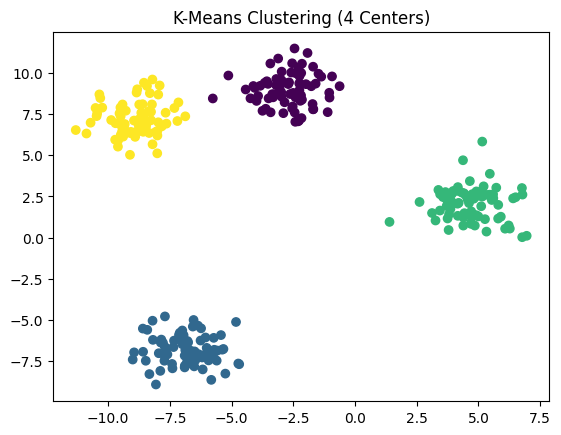

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, _ = make_blobs(n_samples=300, centers=4, random_state=42)
kmeans = KMeans(n_clusters=4, random_state=42).fit(X)
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis')
plt.title("K-Means Clustering (4 Centers)")
plt.show()

**Ques 22.Load the Iris dataset and use Agglomerative Clustering to group the data into 3 clusters. Display the first 10 predicted labels.**

In [2]:
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering

iris = load_iris()
X = iris.data
agg_clust = AgglomerativeClustering(n_clusters=3).fit(X)
print("First 10 labels:", agg_clust.labels_[:10])

First 10 labels: [1 1 1 1 1 1 1 1 1 1]


**Ques 23.Generate synthetic data using make_moons and apply DBSCAN. Highlight outliers in the plot.**

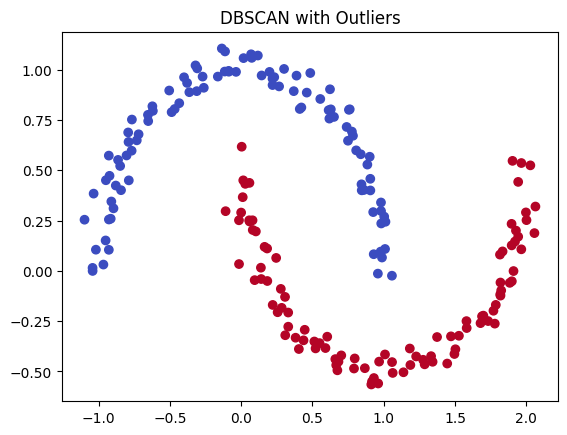

In [3]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

X, _ = make_moons(n_samples=200, noise=0.05, random_state=42)
dbscan = DBSCAN(eps=0.2, min_samples=5).fit(X)
plt.scatter(X[:, 0], X[:, 1], c=dbscan.labels_, cmap='coolwarm')
plt.title("DBSCAN with Outliers")
plt.show()

**Ques 24.Load the Wine dataset and apply K-Means clustering after standardizing the features. Print the size of each cluster.**

In [4]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

wine = load_wine()
X_scaled = StandardScaler().fit_transform(wine.data)
kmeans = KMeans(n_clusters=3, random_state=42).fit(X_scaled)
unique, counts = np.unique(kmeans.labels_, return_counts=True)
print("Cluster sizes:", dict(zip(unique, counts)))

Cluster sizes: {np.int32(0): np.int64(65), np.int32(1): np.int64(51), np.int32(2): np.int64(62)}


**Ques 25. Use make_circles to generate synthetic data and cluster it using DBSCAN. Plot the result.**

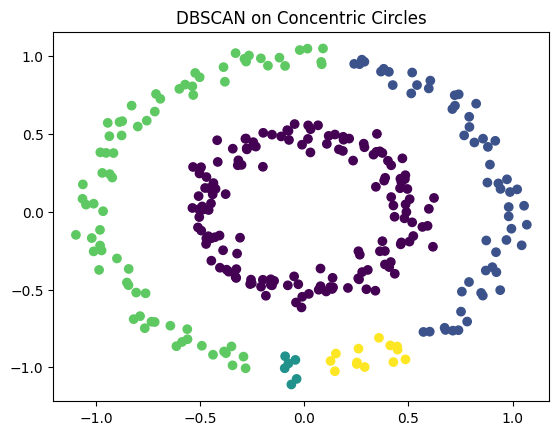

In [5]:
from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

X, _ = make_circles(n_samples=300, factor=0.5, noise=0.05, random_state=42)
dbscan = DBSCAN(eps=0.15, min_samples=5).fit(X)
plt.scatter(X[:, 0], X[:, 1], c=dbscan.labels_, cmap='viridis')
plt.title("DBSCAN on Concentric Circles")
plt.show()

**Ques 26. Load the Breast Cancer dataset, apply MinMaxScaler, and use K-Means with 2 clusters. Output the cluster centroids.**

In [6]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

cancer = load_breast_cancer()
X_scaled = MinMaxScaler().fit_transform(cancer.data)
kmeans = KMeans(n_clusters=2, random_state=42).fit(X_scaled)
print("Centroids:\n", kmeans.cluster_centers_)

Centroids:
 [[0.50483563 0.39560329 0.50578661 0.36376576 0.46988732 0.42226302
  0.41838662 0.46928035 0.45899738 0.29945886 0.19093085 0.19112073
  0.17903433 0.13086432 0.18017962 0.25890126 0.12542475 0.30942779
  0.190072   0.13266975 0.48047448 0.45107371 0.4655302  0.31460597
  0.49868817 0.36391461 0.39027292 0.65827197 0.33752296 0.26041387]
 [0.25535358 0.28833455 0.24696416 0.14388369 0.35743076 0.18019471
  0.10344776 0.1306603  0.34011829 0.25591606 0.06427485 0.18843043
  0.05975663 0.02870108 0.18158628 0.13242941 0.05821528 0.18069336
  0.17221057 0.08403996 0.2052406  0.32069002 0.19242138 0.09943446
  0.3571115  0.14873935 0.13142287 0.26231363 0.22639412 0.15437354]]


**Ques 27.Generate synthetic data using make_blobs with varying cluster standard deviations and cluster with DBSCAN.**

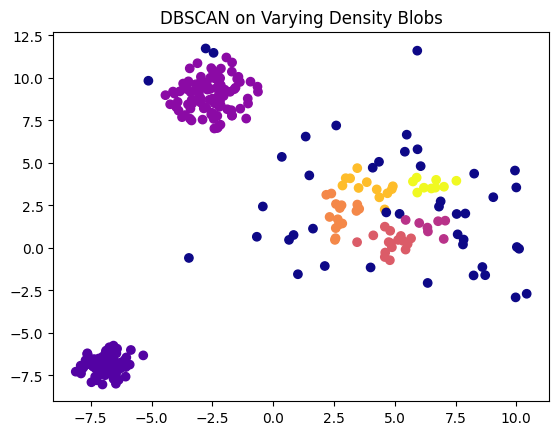

In [7]:
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, cluster_std=[1.0, 2.5, 0.5], random_state=42)
dbscan = DBSCAN(eps=0.8, min_samples=5).fit(X)
plt.scatter(X[:, 0], X[:, 1], c=dbscan.labels_, cmap='plasma')
plt.title("DBSCAN on Varying Density Blobs")
plt.show()

**Ques 28. Load the Digits dataset, reduce it to 2D using PCA, and visualize clusters from K-Means.**

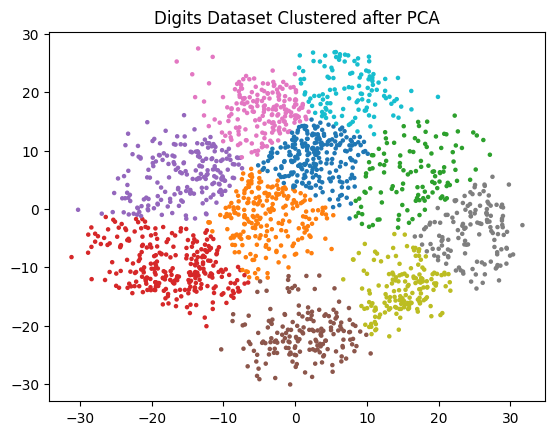

In [8]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

digits = load_digits()
X_pca = PCA(n_components=2).fit_transform(digits.data)
kmeans = KMeans(n_clusters=10, random_state=42).fit(X_pca)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels_, cmap='tab10', s=5)
plt.title("Digits Dataset Clustered after PCA")
plt.show()

**Ques 29. Create synthetic data using make_blobs and evaluate silhouette scores for k=2 to 5. Display as a bar chart.**

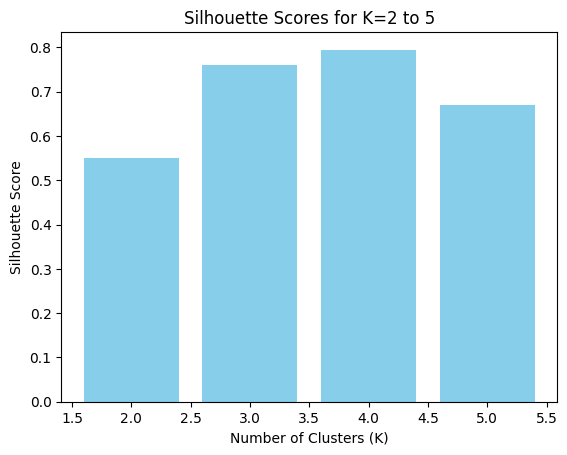

In [9]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=200, centers=4, random_state=42)
scores = []
k_values = range(2, 6)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    scores.append(silhouette_score(X, kmeans.labels_))

plt.bar(k_values, scores, color='skyblue')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for K=2 to 5")
plt.show()

**Ques 30. Load the Iris dataset and use hierarchical clustering to group data. Plot a dendrogram with average linkage.**

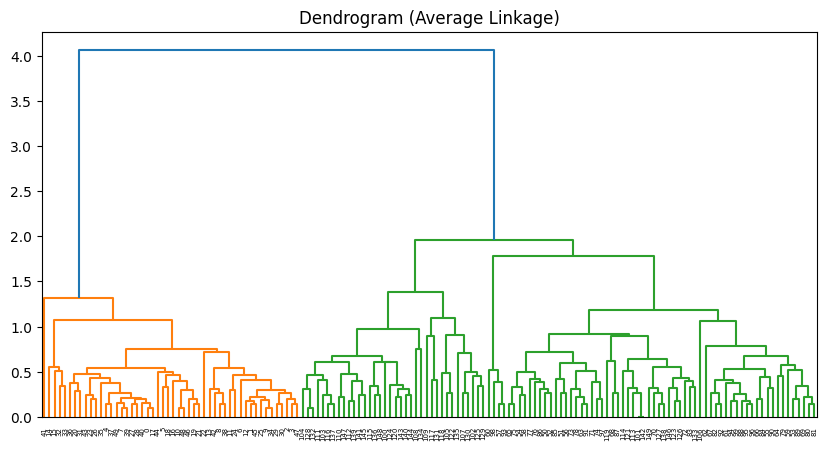

In [10]:
from sklearn.datasets import load_iris
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

iris = load_iris()
Z = linkage(iris.data, method='average')
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Dendrogram (Average Linkage)")
plt.show()

**Ques 31.Generate synthetic data with overlapping clusters using make_blobs, then apply K-Means and visualize with decision boundaries.**

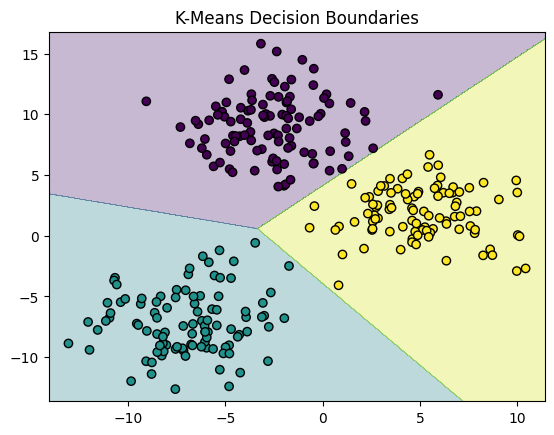

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, _ = make_blobs(n_samples=300, centers=3, cluster_std=2.5, random_state=42)
kmeans = KMeans(n_clusters=3, random_state=42).fit(X)

h = .02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, edgecolor='k', cmap='viridis')
plt.title("K-Means Decision Boundaries")
plt.show()

**Ques 32.Load the Digits dataset and apply DBSCAN after reducing dimensions with t-SNE. Visualize the results.**

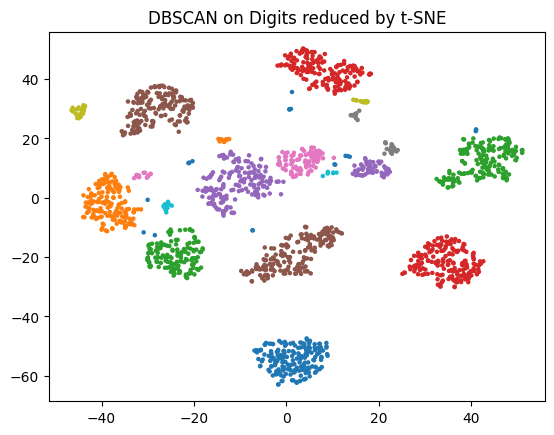

In [12]:
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

digits = load_digits()
X_tsne = TSNE(n_components=2, random_state=42).fit_transform(digits.data)
dbscan = DBSCAN(eps=2.5, min_samples=5).fit(X_tsne)

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=dbscan.labels_, cmap='tab10', s=5)
plt.title("DBSCAN on Digits reduced by t-SNE")
plt.show()

**Ques 33.Generate synthetic data using make_blobs and apply Agglomerative Clustering with complete linkage. Plot the result.**

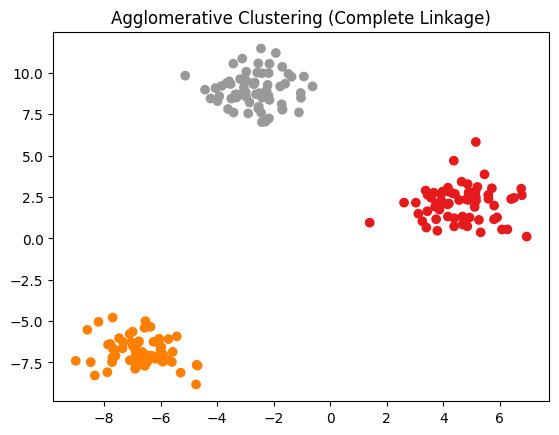

In [13]:
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=200, centers=3, random_state=42)
agg = AgglomerativeClustering(n_clusters=3, linkage='complete').fit(X)
plt.scatter(X[:, 0], X[:, 1], c=agg.labels_, cmap='Set1')
plt.title("Agglomerative Clustering (Complete Linkage)")
plt.show()

**Ques 34.Load the Breast Cancer dataset and compare inertia values for K=2 to 6 using K-Means. Show results in a line plot.**

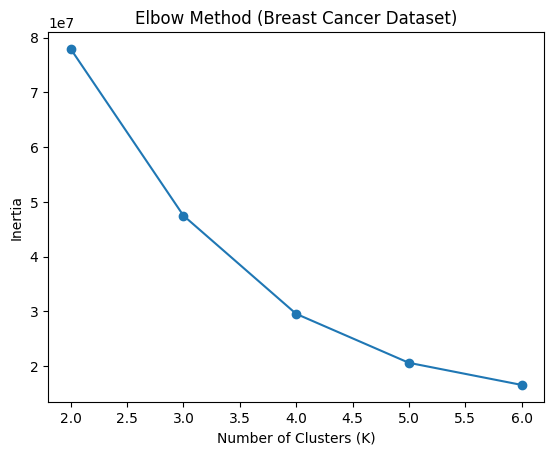

In [14]:
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

cancer = load_breast_cancer()
X = cancer.data
inertias = []
k_values = range(2, 7)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    inertias.append(kmeans.inertia_)

plt.plot(k_values, inertias, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method (Breast Cancer Dataset)")
plt.show()

**Ques 35.Generate synthetic concentric circles using make_circles and cluster using Agglomerative Clustering with single linkage.**

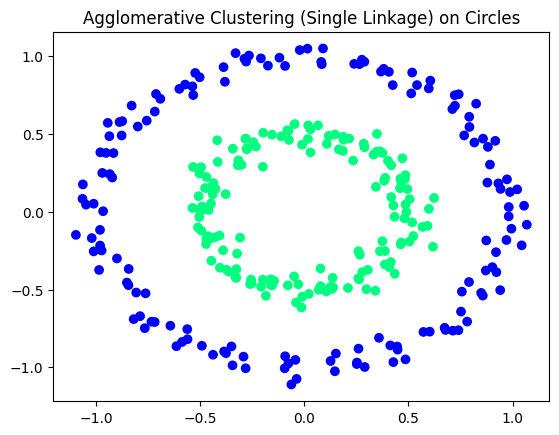

In [16]:
from sklearn.datasets import make_circles
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X, _ = make_circles(n_samples=300, factor=0.5, noise=0.05, random_state=42)
agg = AgglomerativeClustering(n_clusters=2, linkage='single').fit(X)
plt.scatter(X[:, 0], X[:, 1], c=agg.labels_, cmap='winter')
plt.title("Agglomerative Clustering (Single Linkage) on Circles")
plt.show()

**Ques 36.Use the Wine dataset, apply DBSCAN after scaling the data, and count the number of clusters (excluding noise)**

In [17]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np

wine = load_wine()
X_scaled = StandardScaler().fit_transform(wine.data)
dbscan = DBSCAN(eps=2.0, min_samples=5).fit(X_scaled)
n_clusters = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
print(f"Number of clusters found: {n_clusters}")

Number of clusters found: 5


**Ques 37. Generate synthetic data with make_blobs and apply KMeans. Then plot the cluster centers on top of the data points.**

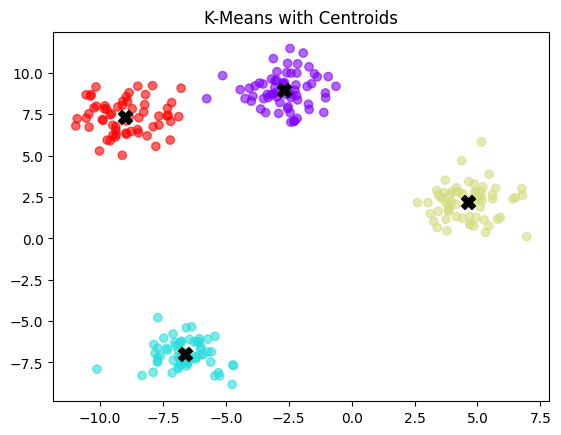

In [18]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=250, centers=4, random_state=42)
kmeans = KMeans(n_clusters=4, random_state=42).fit(X)
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='rainbow', alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='black', s=100, marker='X')
plt.title("K-Means with Centroids")
plt.show()

**Ques 38.Load the Iris dataset, cluster with DBSCAN, and print how many samples were identified as noise.**

In [19]:
from sklearn.datasets import load_iris
from sklearn.cluster import DBSCAN

iris = load_iris()
dbscan = DBSCAN(eps=0.5, min_samples=5).fit(iris.data)
noise_count = list(dbscan.labels_).count(-1)
print(f"Number of noise samples: {noise_count}")

Number of noise samples: 17


**Ques 39.Generate synthetic non-linearly separable data using make_moons, apply K-Means, and visualize the clustering result.**

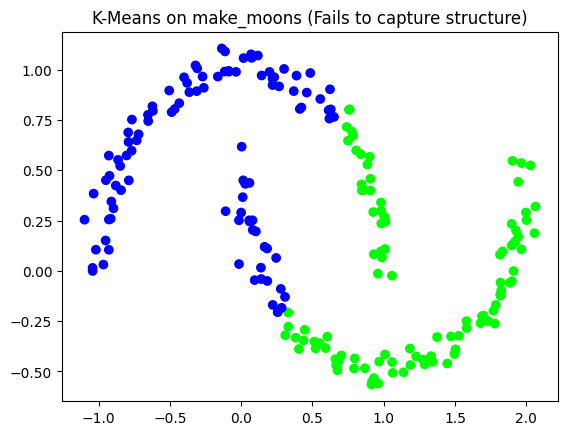

In [20]:
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, _ = make_moons(n_samples=200, noise=0.05, random_state=42)
kmeans = KMeans(n_clusters=2, random_state=42).fit(X)
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='brg')
plt.title("K-Means on make_moons (Fails to capture structure)")
plt.show()

**Ques 40.Load the Digits dataset, apply PCA to reduce to 3 components, then use KMeans and visualize with a 3D scatter plot.**

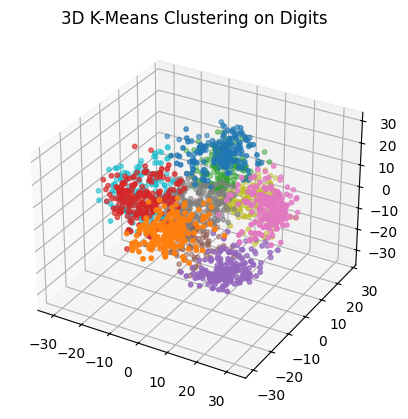

In [21]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

digits = load_digits()
X_pca = PCA(n_components=3).fit_transform(digits.data)
kmeans = KMeans(n_clusters=10, random_state=42).fit(X_pca)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=kmeans.labels_, cmap='tab10', s=10)
plt.title("3D K-Means Clustering on Digits")
plt.show()

**Ques 41.Generate synthetic blobs with 5 centers and apply KMeans. Then use silhouette_score to evaluate the clustering.**

In [22]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X, _ = make_blobs(n_samples=300, centers=5, random_state=42)
kmeans = KMeans(n_clusters=5, random_state=42).fit(X)
score = silhouette_score(X, kmeans.labels_)
print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.6530


**Ques 42.Load the Breast Cancer dataset, reduce dimensionality using PCA, and apply Agglomerative Clustering. Visualize in 2D.**

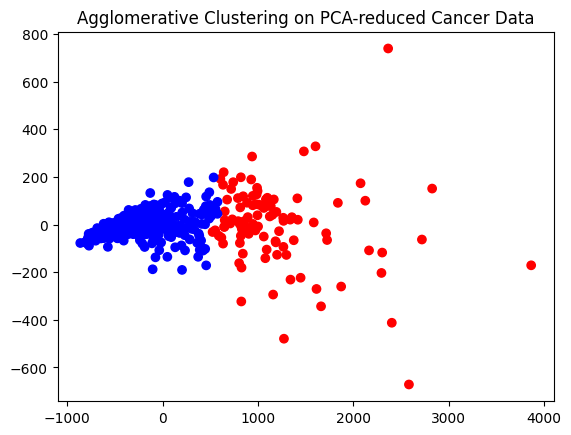

In [23]:
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

cancer = load_breast_cancer()
X_pca = PCA(n_components=2).fit_transform(cancer.data)
agg = AgglomerativeClustering(n_clusters=2).fit(X_pca)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg.labels_, cmap='bwr')
plt.title("Agglomerative Clustering on PCA-reduced Cancer Data")
plt.show()

**Ques 43.Generate noisy circular data using make_circles and visualize clustering results from KMeans and DBSCAN side-by-side.**

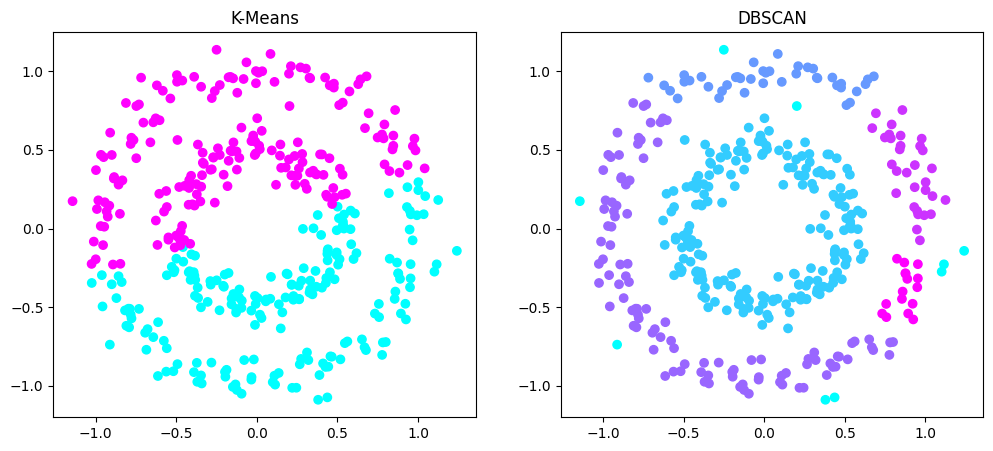

In [24]:
from sklearn.datasets import make_circles
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt

X, _ = make_circles(n_samples=400, factor=0.5, noise=0.08, random_state=42)
kmeans = KMeans(n_clusters=2, random_state=42).fit(X)
dbscan = DBSCAN(eps=0.15, min_samples=5).fit(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='cool')
axes[0].set_title("K-Means")
axes[1].scatter(X[:, 0], X[:, 1], c=dbscan.labels_, cmap='cool')
axes[1].set_title("DBSCAN")
plt.show()

**Ques 44.Load the Iris dataset and plot the Silhouette Coefficient for each sample after KMeans clustering.**


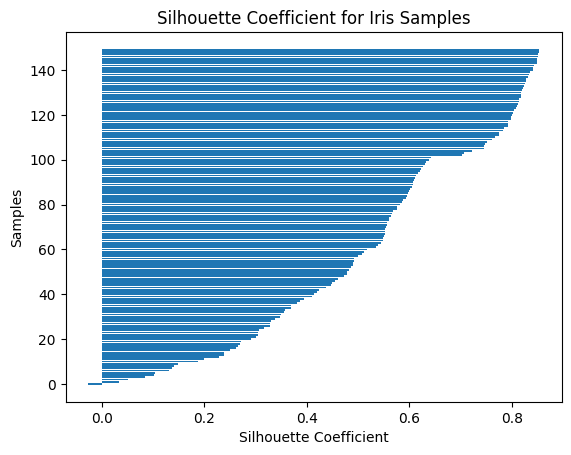

In [25]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt
import numpy as np

iris = load_iris()
X = iris.data
kmeans = KMeans(n_clusters=3, random_state=42).fit(X)
sample_scores = silhouette_samples(X, kmeans.labels_)

plt.barh(range(len(sample_scores)), np.sort(sample_scores))
plt.ylabel("Samples")
plt.xlabel("Silhouette Coefficient")
plt.title("Silhouette Coefficient for Iris Samples")
plt.show()

**Ques 45.Generate synthetic data using make_blobs and apply Agglomerative Clustering with 'average' linkage. Visualize clusters.**

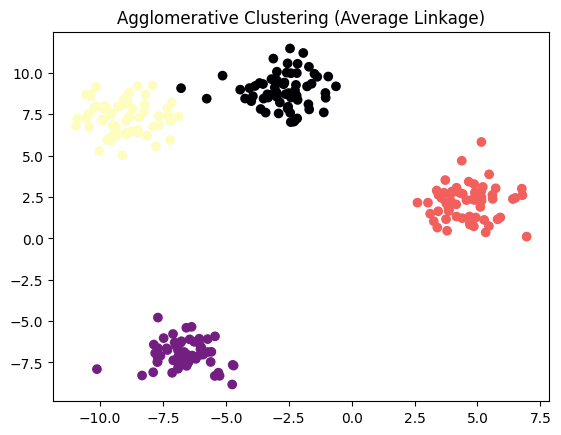

In [26]:
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=250, centers=4, random_state=42)
agg = AgglomerativeClustering(n_clusters=4, linkage='average').fit(X)
plt.scatter(X[:, 0], X[:, 1], c=agg.labels_, cmap='magma')
plt.title("Agglomerative Clustering (Average Linkage)")
plt.show()

**Ques 46.Load the Wine dataset, apply KMeans, and visualize the cluster assignments in a seaborn pairplot (first 4 features).**

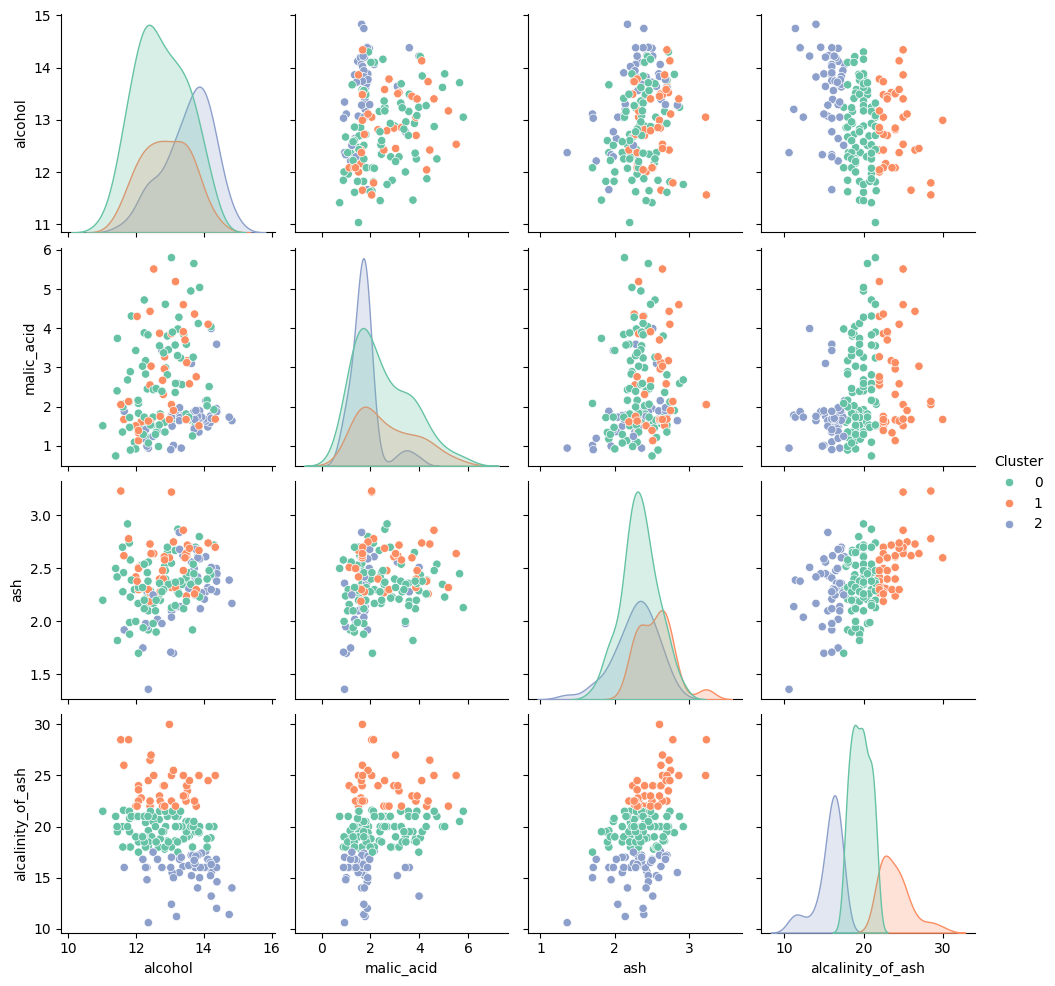

In [27]:
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

wine = load_wine()
df = pd.DataFrame(wine.data[:, :4], columns=wine.feature_names[:4])
kmeans = KMeans(n_clusters=3, random_state=42).fit(df)
df['Cluster'] = kmeans.labels_

sns.pairplot(df, hue='Cluster', palette='Set2')
plt.show()

**Ques 47.Generate noisy blobs using make_blobs and use DBSCAN to identify both clusters and noise points. Print the count.**

In [28]:
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
import numpy as np

X, _ = make_blobs(n_samples=300, cluster_std=3.0, random_state=42)
dbscan = DBSCAN(eps=1.5, min_samples=5).fit(X)
clusters = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
noise = list(dbscan.labels_).count(-1)

print(f"Clusters identified: {clusters}")
print(f"Noise points identified: {noise}")

Clusters identified: 5
Noise points identified: 40


**Ques 48. Load the Digits dataset, reduce dimensions using t-SNE, then apply Agglomerative Clustering and plot the clusters.**

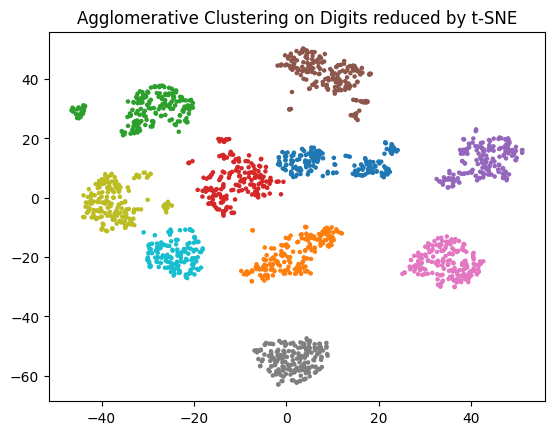

In [29]:
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

digits = load_digits()
X_tsne = TSNE(n_components=2, random_state=42).fit_transform(digits.data)
agg = AgglomerativeClustering(n_clusters=10).fit(X_tsne)

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=agg.labels_, cmap='tab10', s=5)
plt.title("Agglomerative Clustering on Digits reduced by t-SNE")
plt.show()